# Exercise 2

In [48]:
import tensorflow as tf
from autograd import numpy as np
import pandas as pd

from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [49]:
train_labels.shape=(1,60000)
test_labels.shape=(1,10000)
train_images=(train_images.reshape(60000,784)).T
test_images=(test_images.reshape(10000,784)).T
print(train_images.shape)
print(test_images.shape)
print(train_labels.shape)
print(test_labels.shape)
print(train_images.dtype)
print(train_labels.dtype)

(784, 60000)
(784, 10000)
(1, 60000)
(1, 10000)
uint8
uint8


In [50]:
# compute C linear combinations of input point, one per classifier
def model(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return a.T

# multiclass perceptron
def multiclass_perceptron(w,x,y,iter):
    # get subset of points
    x_p = x[:,iter]
    y_p = y[:,iter]

    # pre-compute predictions on all points
    all_evals = model(x_p,w)

    # compute maximum across data points
    a =  np.max(all_evals,axis = 0)        

    # compute cost in compact form using numpy broadcasting
    b = all_evals[y_p.astype(int).flatten(),np.arange(np.size(y_p))]
    cost = np.sum(a - b)

    # return average
    return cost/float(np.size(y_p))

## Exerxise 2.1

In [51]:
from autograd import grad
from autograd.misc.flatten import flatten_func

def gradient_descent(g, w, cost_func, x_train, y_train, alpha, max_its, batch_size):

    # flatten g and w
    g_flat, unflatten, w_flat = flatten_func(g, w)

    # number of training samples
    num_train = x_train.shape[1]
    num_batches = int(np.ceil(num_train / batch_size))

    weight_history = [w]
    # use cost function (not gradient) for logging
    cost_history = [cost_func(w, x_train, y_train)]

    # gradient descent loop
    for k in range(max_its):

        for b in range(num_batches):
            # batch indices
            batch_inds = np.arange(b * batch_size, min((b + 1) * batch_size, num_train))

            # extract batch
            x_batch = x_train[:, batch_inds]
            y_batch = y_train[:, batch_inds]

            # compute gradient in flat form
            grad_flat = g_flat(w_flat, x_batch, y_batch)

            # update flat weights
            w_flat = w_flat - alpha * grad_flat

        # unflatten for cost evaluation
        w_struct = unflatten(w_flat)

        # record weight and cost
        weight_history.append(w_struct)
        cost_history.append(cost_func(w_struct, x_train, y_train))

    return weight_history, cost_history


If the batch size does not divide the training set evenly, I let the final batch be smaller by cutting off at $num\_train$ when constructing the batch indices.

## Exercise 2.2

In [52]:
N = 784
C = 10

max_its = 5
w0 = 0.1*np.random.randn(N+1,C)
alpha = 0.001

# define cost and gradient separately
cost_func = lambda w, x, y: multiclass_perceptron(w, x, y, np.arange(x.shape[1]))
g = grad(cost_func)

batch_size_1 = 200
batch_size_2 = train_images.shape[1]

weight_hist_1, cost_history_1 = gradient_descent(g, w0.copy(), cost_func, train_images, train_labels, alpha, max_its, batch_size_1)
weight_hist_2, cost_history_2 = gradient_descent(g, w0.copy(), cost_func, train_images, train_labels, alpha, max_its, batch_size_2)

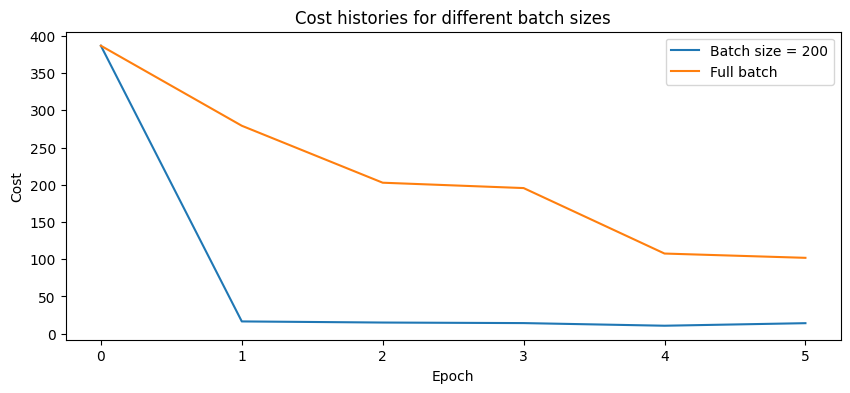

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(cost_history_1, label="Batch size = 200")
plt.plot(cost_history_2, label="Full batch")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Cost histories for different batch sizes")
plt.legend()
plt.show()

The batch size of 200 performs better. It decreases the cost faster because it produces many more weight updates per epoch and benefits from the stochasticity of mini‑batch gradient descent. The full batch method is more stable but converges significantly slower and therefore requires more iterations.

## Exercise 2.3

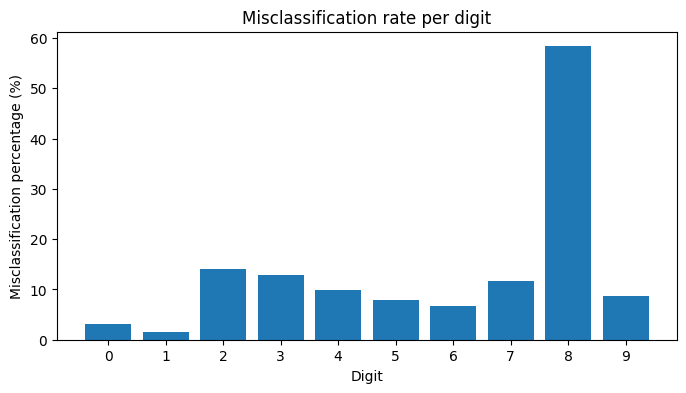

In [54]:
best_w = weight_hist_1[-1]

# compute predictions on test set
logits = model(test_images, best_w)
y_pred = np.argmax(logits, axis=0)

# true labels
y_true = test_labels.flatten()

# compute misclassification percentage per digit
misclass_percent = []

for digit in range(10):
    index = np.where(y_true == digit)[0]
    num_digit = len(index)
    wrong_pred = np.sum(y_pred[index] != digit)
    misclass_percent.append(100 * wrong_pred / num_digit)

# plot histogram
plt.figure(figsize=(8,4))
plt.bar(range(10), misclass_percent)
plt.xlabel("Digit")
plt.ylabel("Misclassification percentage (%)")
plt.title("Misclassification rate per digit")
plt.xticks(range(10))
plt.show()


Yes, the digit 8 is the most misclassified digit. One possible reason is that the digit 8 has a more complex structure than many of the other digits, which makes it harder for the model to classify correctly. The digit 8 can also resemble other digits, such as 3 or 9, depending on handwriting style, which can lead to confusion for the classifier.